Loading interaction matrix: IM_pushpull_1024act_251164px_512pup_512wfs_q3_mod3x16_c0.1_poke20nm_wl1500nm.npy


AO flat reference: 100%|██████████| 1000/1000 [19:01<00:00,  1.14s/it]



=== r0-0.6_gain-0.6_up-0.6_ncpa-on_burn-50_cycle-100_nbest-10_alpha-0.9   (r0 0.6 m = 0.51" seeing @ 1.5 um, gain 0.6, upstream 0.6, NCPA on) ===
FINAL PERFORMANCE (last 200 iterations)
--------------------------------------------------------------------------------
flat reference   | WFS   92.7 nm | science  135.9 nm | Strehl 0.7628 | no-NCPA 0.8688 | flux_concentration 0.002691
DrWHO            | WFS   98.6 nm | science  124.7 nm | Strehl 0.8031 | no-NCPA 0.8505 | flux_concentration 0.002925

Best individual DrWHO-run exposure by flux_concentration: iteration 954, Strehl 0.8380

DrWHO UPDATE HISTORY   (score = flux_concentration; NCPA left/NCPA < 1 means the reference is cancelling NCPA)
(the first row also includes the burn-in frames)
 iter | reference score | cycle mean | cycle best | new ref | pool | NCPA left / NCPA
  149 |          0.0029 |   0.002826 |   0.002945 |     yes |   10 |    0.950
  249 |         0.00285 |   0.002794 |    0.00288 |     yes |   10 |    0.914
  349 |  

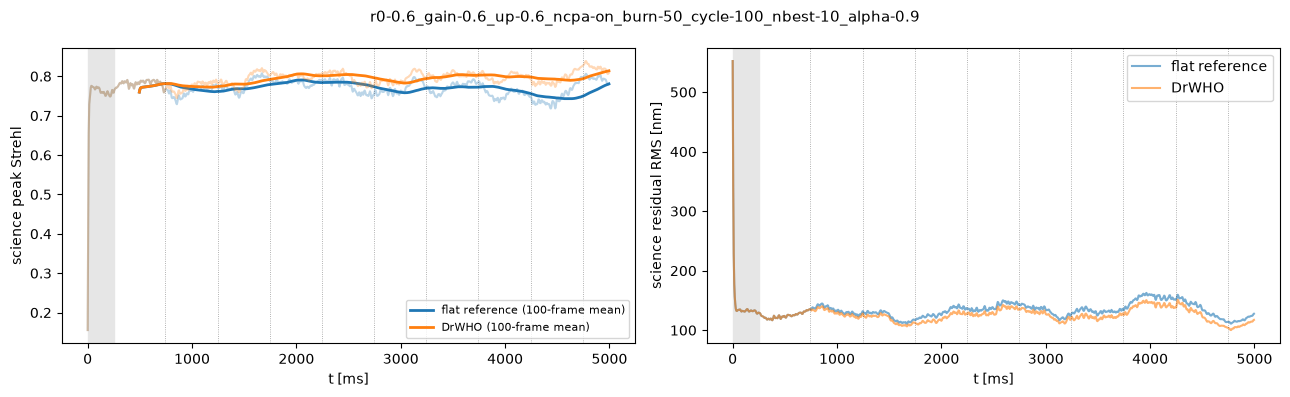

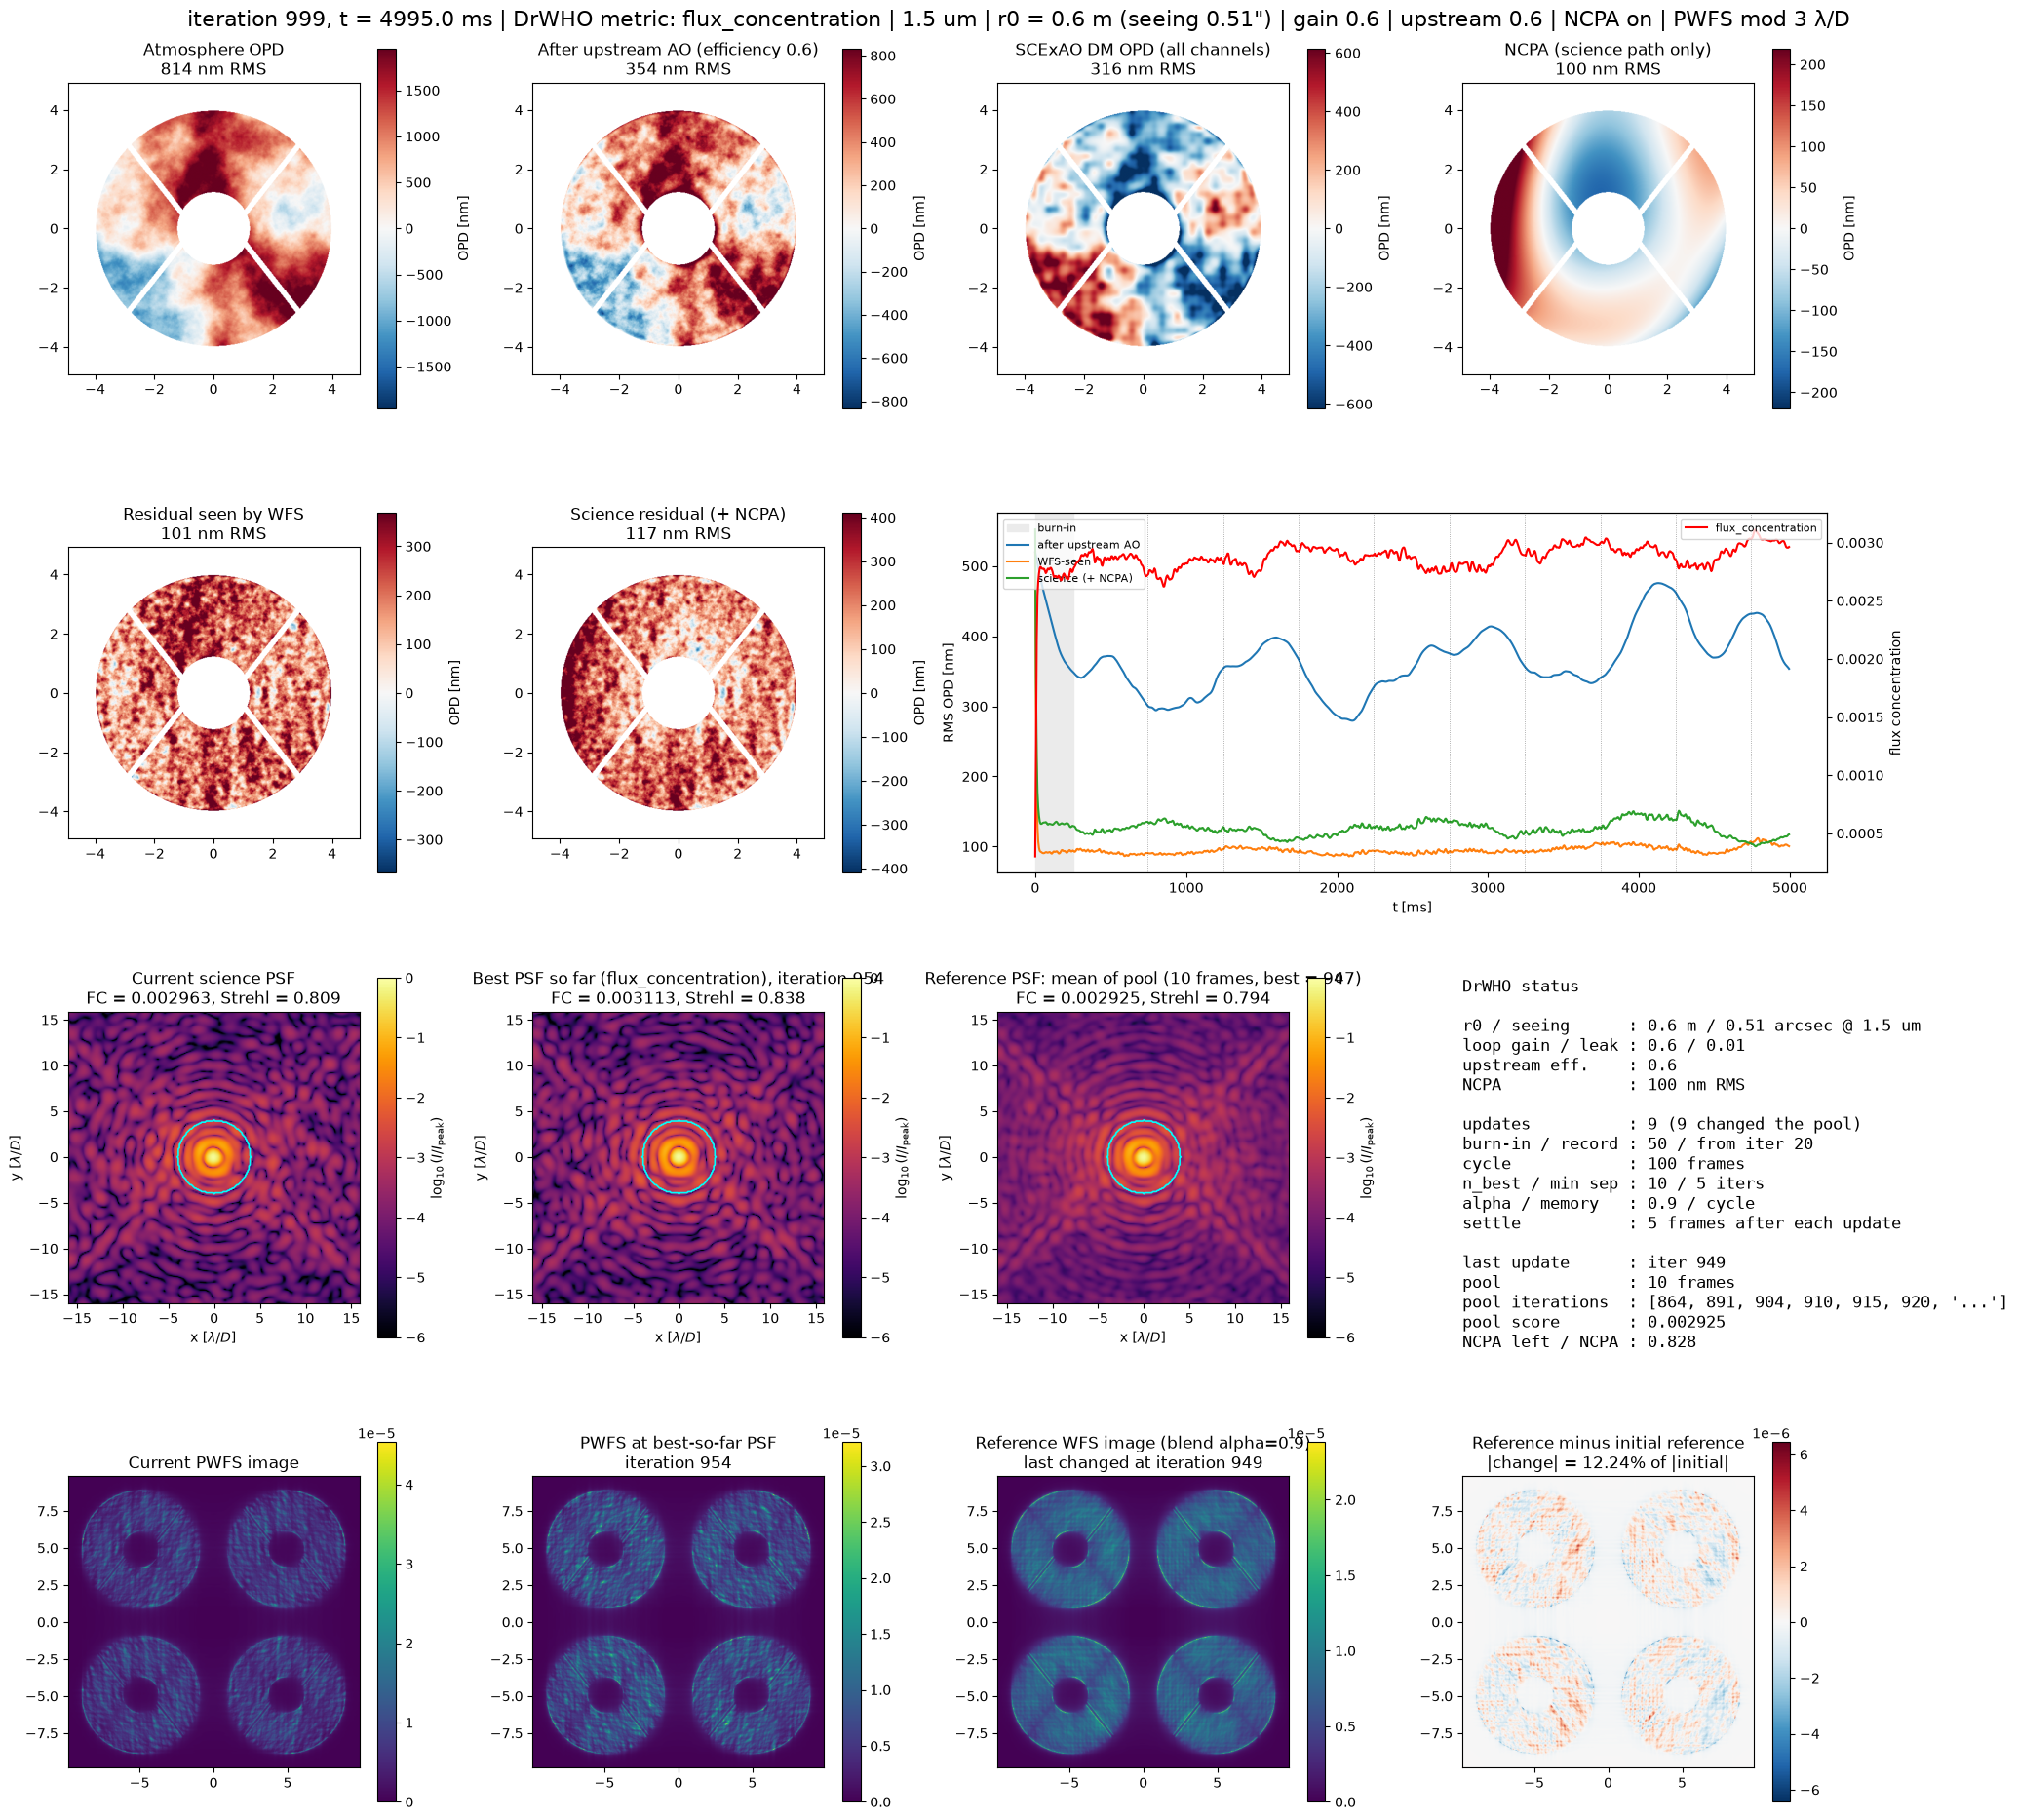

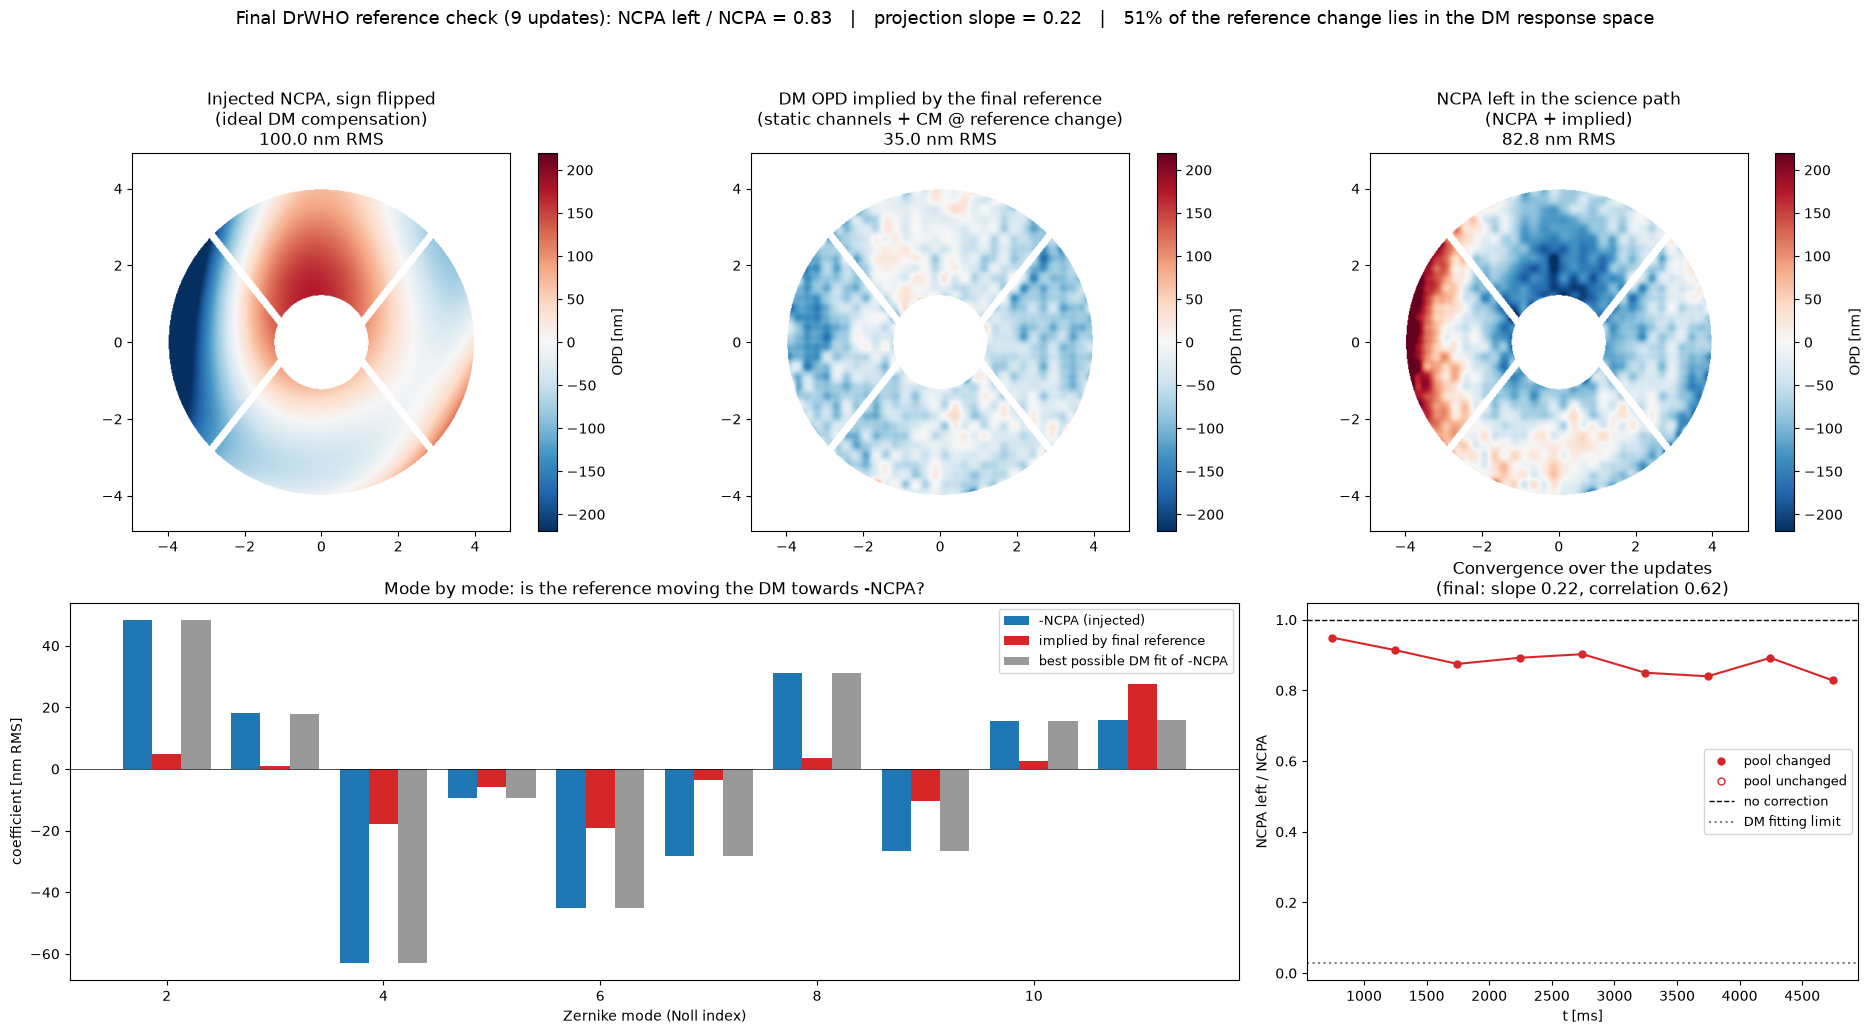

FINAL REFERENCE CHECK
------------------------------------------------------------------
injected NCPA                           :  100.00 nm RMS
best possible DM fit of -NCPA           :   99.93 nm RMS  (DM fitting limit)
DM OPD implied by the final reference   :   35.00 nm RMS
NCPA left after that compensation       :   82.81 nm RMS  -> NCPA left / NCPA = 0.828
projection onto -NCPA (1 = perfect)     :   0.218   correlation 0.624
reference change inside response space  :     51%   (the rest is noise or modes the DM cannot make)
implied OPD power in the NCPA modes     :   89.8 %  (Noll 2-11)
frame-to-frame diversity in the 10 NCPA modes: 160.1 nm RMS
NCPA in those modes: 108.3 nm RMS
corr(score, NCPA cancellation): -0.361
autocorrelation of the cancellation: lag 1: 1.00, lag 5: 0.99, lag 10: 0.98, lag 50: 0.80


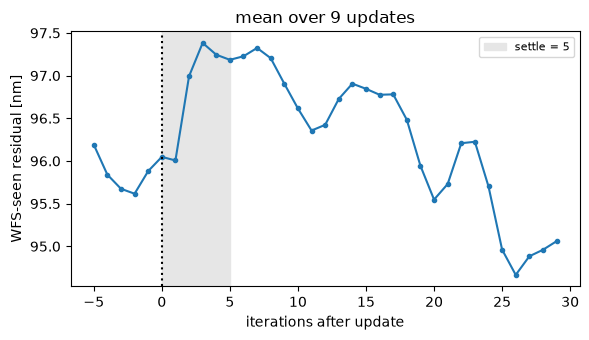

   10 nm RMS on the DM -> measured fraction 0.80
   25 nm RMS on the DM -> measured fraction 0.79
   50 nm RMS on the DM -> measured fraction 0.78
  100 nm RMS on the DM -> measured fraction 0.73
  150 nm RMS on the DM -> measured fraction 0.71
  200 nm RMS on the DM -> measured fraction 0.69
  300 nm RMS on the DM -> measured fraction 0.59


In [2]:
# ============================================================
# DrWHO AO loop v7: whole system at 1 um, NCPA on/off switch, adjustable upstream AO, settling after updates,
#                   per-cycle memory by default, convergence panel in the reference check, diversity diagnostics
#
# Each "# %%" block is one notebook cell. Run top to bottom.
#
# DrWHO schedule:
#   0 .. drwho_record_from-1        loop closing, nothing recorded
#   drwho_record_from .. burn_in-1  plain AO on the flat reference; frames ARE recorded as candidates
#   then cycles of drwho_cycle frames; at the end of each cycle every recorded frame competes with the pool of
#   best frames kept from all earlier cycles (burn-in included); the top drwho_n_best become the new pool and
#   their mean WFS image is the new reference. Selected frames must be at least drwho_min_separation iterations
#   apart, so the pool is made of (more) independent atmosphere realisations.
# ============================================================

# %% 0. Imports + settings
import os
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
from hcipy import *
from tqdm import tqdm

# --- telescope / sensing ---
D_tel = 8.2
wfs_wl = 1.5e-6                 # wavelength of the WHOLE system (WFS + science) [m]
num_pupil_pixels = 512
pwfs_num_pixels = 512
pwfs_q = 3
pwfs_modulation = 3.0           # modulation radius [lambda/D]; 0 = unmodulated pyramid
pwfs_mod_steps = 16             # modulation points per frame (spacing ~ 2*pi*radius/steps lambda/D)
pwfs_fast_modulation = True     # HCIPy: one focal-plane FFT, shifted pyramids (much faster, same intensities)
science_q = 8
science_num_airy = 16

# --- atmosphere ---
r0 = 0.6                       # Fried parameter at wfs_wl [m]  (0.46 m at 1 um = 0.20 m at 500 nm)
L0 = 20.0                       # outer scale [m]
atmosphere_seed = 10            # set an int for a reproducible atmosphere
seeing_arcsec = 0.98 * 206265 * (wfs_wl / r0)      # seeing FWHM at wfs_wl [arcsec]

# --- deformable mirror ---
num_actuators_across_pupil = 32
dm_coupling = 0.1

# --- WFS detector ---
photon_rate = 3.5e10            # photons / s
dark_current_rate = 0.01
read_noise = 0.3
flat_field = 0.0
include_photon_noise = False

# --- AO loop ---
loop_rate_hz = 200
dt = 1.0 / loop_rate_hz         # frame time == WFS exposure time
gain = 0.6
leakage = 0.01                  # FIX: 0.05 left ~l/(g+l) = 11% of every slow disturbance (and of the DrWHO offset)
tikhonov = 0.01                 # relative to sigma_max
upstream_efficiency = 0.6       # fraction of the first 200 Zernikes removed upstream (1 = perfect woofer)
poke = 20e-9                    # DM surface poke for the interaction matrix [m]
n_iter = 1000

# --- NCPA (science path only) ---
use_ncpa = True                 # False = control run: no NCPA at all (run_loop / run_case can override)
ncpa_rms = 100e-9
ncpa_num_modes = 10
ncpa_correlation = 1            # per-frame AR(1) correlation; 1.0 = perfectly static
ncpa_seed = 123

# --- DrWHO ---
use_drwho = True
drwho_burn_in = 50              # iterations on the flat reference before the first reference update
drwho_record_from = 20          # first iteration recorded as a candidate (skips the loop-closing transient);
                                # = drwho_burn_in means burn-in frames are not used
drwho_cycle = 100               # frames per DrWHO cycle; the reference is updated at the end of each cycle
drwho_n_best = 10               # size of the best-frame pool (~10% of a cycle); reference = mean WFS image of the pool
drwho_min_separation = 5        # selected frames must be >= this many iterations apart (1 = no constraint)
drwho_alpha = 0.9               # 1.0 = replace the reference; <1 = blend with the old one
drwho_settle = 5               # frames NOT recorded after each reference update (loop moving to the new reference)
drwho_memory = "cycle"          # "cycle": only frames recorded under the current reference compete (as in the paper)
                                # "all": the pool also competes with every earlier frame (can lock in)


# %% 1. Unit helpers
def phase_to_opd(phase, wavelength):
    return np.asarray(phase) * wavelength / (2 * np.pi)


def opd_to_phase(opd, wavelength):
    return 2 * np.pi * np.asarray(opd) / wavelength


# %% 2. Multi-channel DM
class MultiChannelDM:
    """
    HCIPy DeformableMirror with named command channels.  Physical command = sum of ENABLED channels.

      * Anything that should persist is written to a channel with set()/add()/clear().
      * dm.actuators is the PHYSICAL array. Writing to it directly (calibration, quick tests) is allowed,
        but the next apply()/enable()/disable()/set()/clear() overwrites it with the channel sum.
      * Channels other than the loop channel are static offsets that the loop deliberately does NOT fight
        (see run_loop: their WFS response is subtracted from the measurement).
    """

    def __init__(self, dm):
        self.dm = dm
        self.n_act = len(dm.actuators)
        self.channels = {}
        self.enabled = {}

    def __getattr__(self, name):
        # forward everything else (influence_functions, surface, num_actuators, ...) to the HCIPy DM
        if name in ("dm", "channels", "enabled"):
            raise AttributeError(name)
        return getattr(self.dm, name)

    # ---- channel management ----
    def _check_channel(self, name):
        if name not in self.channels:
            raise KeyError(f"Unknown DM channel '{name}'. Available: {list(self.channels)}")

    def _check_command(self, command):
        command = np.asarray(command, dtype=float)
        if command.shape != (self.n_act,):
            raise ValueError(f"Command must have shape ({self.n_act},), got {command.shape}.")
        return command

    def add_channel(self, name, command=None, enabled=True):
        if name in self.channels:
            raise ValueError(f"Channel '{name}' already exists.")
        command = np.zeros(self.n_act) if command is None else self._check_command(command)
        self.channels[name] = command.copy()
        self.enabled[name] = enabled
        self.apply()

    def remove_channel(self, name):
        self._check_channel(name)
        del self.channels[name]
        del self.enabled[name]
        self.apply()

    def enable(self, name):
        self._check_channel(name)
        self.enabled[name] = True
        self.apply()

    def disable(self, name):
        self._check_channel(name)
        self.enabled[name] = False
        self.apply()

    # ---- commands ----
    def set(self, name, command, apply=True):
        self._check_channel(name)
        self.channels[name][:] = self._check_command(command)
        if apply:
            self.apply()

    def add(self, name, command, apply=True):
        self._check_channel(name)
        self.channels[name] += self._check_command(command)
        if apply:
            self.apply()

    def get(self, name):
        self._check_channel(name)
        return self.channels[name].copy()

    def clear(self, name, apply=True):
        self._check_channel(name)
        self.channels[name][:] = 0
        if apply:
            self.apply()

    # ---- combined command ----
    @property
    def command(self):
        total = np.zeros(self.n_act)
        for name, command in self.channels.items():
            if self.enabled[name]:
                total += command
        return total

    def command_excluding(self, name):
        """Sum of all enabled channels except `name` (= the static offsets seen by the loop channel)."""
        total = np.zeros(self.n_act)
        for other, command in self.channels.items():
            if other != name and self.enabled[other]:
                total += command
        return total

    def apply(self):
        self.dm.actuators[:] = self.command

    def flatten(self):
        for name in self.channels:
            self.channels[name][:] = 0
        self.apply()

    # ---- HCIPy interface ----
    @property
    def actuators(self):
        return self.dm.actuators

    @actuators.setter
    def actuators(self, value):
        self.dm.actuators[:] = value

    @property
    def opd(self):
        return self.dm.opd

    def forward(self, wavefront):
        return self.dm.forward(wavefront)

    def backward(self, wavefront):
        return self.dm.backward(wavefront)

    def summary(self):
        print("DM channels")
        print("-" * 45)
        for name, command in self.channels.items():
            print(f"{name:15s} {'ON' if self.enabled[name] else 'OFF':3s} {np.std(command) * 1e9:8.2f} nm RMS")
        print("-" * 45)
        print(f"{'TOTAL':15s}     {np.std(self.command) * 1e9:8.2f} nm RMS")


# %% 3. System builder
def make_atmosphere(pupil_grid, r0_, seed=None):
    """Mauna Kea layers scaled to Fried parameter r0_ [m at 500 nm]. Same seed -> same screens for any r0."""
    Cn2 = Cn_squared_from_fried_parameter(r0_, wavelength=wfs_wl)
    layers = make_mauna_kea_atmospheric_layers(pupil_grid, cn_squared=Cn2, outer_scale=L0)
    if seed is not None:
        # np.random.seed() does not touch HCIPy's layers (each draws its own generator from OS entropy)
        for i, layer in enumerate(layers):
            layer._original_rng = np.random.default_rng([seed, i])
            layer.reset()
    return MultiLayerAtmosphere(layers, scintillation=False)


def build_system(seed=None):
    """Everything the loop needs, in one call."""
    pupil_grid_diameter = 1.2 * D_tel
    pupil_grid = make_pupil_grid(num_pupil_pixels, pupil_grid_diameter)
    pwfs_grid = make_pupil_grid(pwfs_num_pixels, 2 * pupil_grid_diameter)
    aperture = evaluate_supersampled(make_subaru_aperture(), pupil_grid, 4)

    pwfs = PyramidWavefrontSensorOptics(pupil_grid, pwfs_grid, separation=pupil_grid_diameter,
                                        pupil_diameter=D_tel, wavelength_0=wfs_wl, q=pwfs_q)
    if pwfs_modulation > 0:
        # HCIPy takes the modulation RADIUS in radians on sky; forward() returns one wavefront per step
        pwfs = ModulatedPyramidWavefrontSensorOptics(pwfs, pwfs_modulation * wfs_wl / D_tel,
                                                     num_steps=pwfs_mod_steps,
                                                     fast_modulation_method=pwfs_fast_modulation)

    focal_grid = make_focal_grid(q=science_q, num_airy=science_num_airy, spatial_resolution=wfs_wl / D_tel,
                                 reference_wavelength=wfs_wl)
    propagator = FraunhoferPropagator(pupil_grid, focal_grid)

    atmosphere = make_atmosphere(pupil_grid, r0, seed)

    influence = make_gaussian_influence_functions(pupil_grid, num_actuators_across_pupil,
                                                  D_tel / num_actuators_across_pupil, crosstalk=dm_coupling)
    dm = MultiChannelDM(DeformableMirror(influence))
    dm.add_channel("ao")                  # the loop's integrator channel

    return SimpleNamespace(pupil_grid=pupil_grid, pwfs_grid=pwfs_grid, aperture=aperture, pwfs=pwfs,
                           focal_grid=focal_grid, propagator=propagator, atmosphere=atmosphere, dm=dm)


S = build_system(seed=atmosphere_seed)
pupil_grid, pwfs_grid, subaru_aperture = S.pupil_grid, S.pwfs_grid, S.aperture
pwfs, focal_grid, science_propagator = S.pwfs, S.focal_grid, S.propagator
atmosphere, dm = S.atmosphere, S.dm

# one atmosphere kept in memory at a time (a 512-px multi-layer atmosphere is large); rebuilt when r0 changes
_atm_cache = {"key": (r0, atmosphere_seed), "atm": atmosphere}


def get_atmosphere(r0_):
    key = (r0_, atmosphere_seed)
    if _atm_cache["key"] != key:
        print(f"Building atmosphere for r0 = {r0_:g} m")
        _atm_cache.update(key=key, atm=make_atmosphere(pupil_grid, r0_, atmosphere_seed))
    return _atm_cache["atm"]


def seeing_from_r0(r0_):
    return 0.98 * 206265 * wfs_wl / r0_          # seeing FWHM at 500 nm [arcsec]


# %% 4. Loop helpers (OPD in metres everywhere; the aperture is applied exactly once, in make_wavefront)
pupil = np.asarray(subaru_aperture)
mask = pupil > 0.5
n_pix = pupil_grid.size
n_act = dm.n_act


def atmosphere_opd(t, atm=None):
    atm = atmosphere if atm is None else atm
    atm.evolve_until(t)
    return phase_to_opd(atm.phase_for(wfs_wl), wfs_wl)          # unwrapped [m]


def make_wavefront(opd):
    return Wavefront(Field(pupil * np.exp(1j * opd_to_phase(opd, wfs_wl)), pupil_grid), wfs_wl)


def rms_nm(opd):
    return np.std(np.asarray(opd)[mask]) * 1e9                         # std() already removes piston


def build_upstream_ao(num_modes=150):
    """Idealised upstream correction: least-squares Zernike fit to the true OPD, pseudo-inverse built once.
    FIX: the efficiency is now an argument of upstream_ao itself (it used to be frozen when this cell ran)."""
    zern = np.asarray(make_zernike_basis(num_modes, D_tel, pupil_grid, starting_mode=2).transformation_matrix)
    zern_pinv = np.linalg.pinv(zern[mask])

    def upstream_ao(opd, efficiency=None):
        efficiency = upstream_efficiency if efficiency is None else efficiency
        return opd - efficiency * (zern @ (zern_pinv @ opd[mask]))

    return zern, upstream_ao


zern, upstream_ao = build_upstream_ao()
ncpa_basis = zern[:, :ncpa_num_modes]
ncpa_pinv = np.linalg.pinv(ncpa_basis[mask])          # OPD -> NCPA-mode coefficients (diversity diagnostics)

# DM influence matrix (sparse): surface = T @ actuators, OPD = 2 * surface (HCIPy: dm.opd = 2 * dm.surface)
T_dm = dm.influence_functions.transformation_matrix.tocsr()


def dm_opd_from_command(actuators):
    return 2 * (T_dm @ np.asarray(actuators))


def fit_dm_to_opd(opd, reg=1e-3):
    """Actuator command (surface, metres) whose DM OPD best matches `opd` over the pupil (ridge least squares)."""
    A = 2 * T_dm[mask]
    AtA = (A.T @ A).toarray()
    AtA += reg * np.trace(AtA) / n_act * np.eye(n_act)
    return np.linalg.solve(AtA, A.T @ np.asarray(opd)[mask])


def initial_ncpa(seed=None, rms=None):
    """The NCPA map at t=0 (also what run_loop starts from). Returns map, unit coefficients, scale."""
    rng = np.random.default_rng(ncpa_seed if seed is None else seed)
    z0 = rng.standard_normal(ncpa_num_modes)
    scale = (ncpa_rms if rms is None else rms) / np.std((ncpa_basis @ z0)[mask])
    return scale * (ncpa_basis @ z0), z0, scale


# %% 5. PWFS: detectors, reference, interaction matrix, control matrix
noisy_cam = NoisyDetector(pwfs_grid, dark_current_rate=dark_current_rate, read_noise=read_noise,
                          flat_field=flat_field, include_photon_noise=include_photon_noise)
clean_cam = NoiselessDetector(pwfs_grid)


def pwfs_image(wf, cam):
    """Normalised PWFS frame. With modulation, the exposure is split evenly over the modulation steps."""
    out = pwfs.forward(wf)
    steps = out if isinstance(out, (list, tuple)) else [out]
    for w in steps:
        w.total_power = photon_rate
        cam.integrate(w, dt / len(steps))
    img = np.asarray(cam.read_out(), dtype=float)
    total = img.sum()
    if total <= 0:
        raise RuntimeError("PWFS detector returned zero or negative flux.")
    return img / total


flat_wf = make_wavefront(np.zeros(n_pix))
ref = pwfs_image(flat_wf, clean_cam)               # noiseless -> one frame is enough
valid = ref > 1e-3 * ref.max()                     # only pixels that carry light


def build_interaction_matrix():
    saved = dm.actuators.copy()
    IM = np.zeros((valid.sum(), n_act))
    for i in tqdm(range(n_act), desc="Building interaction matrix"):
        dm.actuators[:] = 0
        dm.actuators[i] = +poke
        plus = pwfs_image(dm.forward(flat_wf), clean_cam)
        dm.actuators[i] = -poke
        minus = pwfs_image(dm.forward(flat_wf), clean_cam)
        IM[:, i] = (plus - minus)[valid] / (2 * poke)          # push-pull, per metre of actuator
    dm.actuators[:] = saved
    return IM


def static_reference(static_cmd):
    """
    WFS-signal offset (valid pixels) produced by a static DM shape: the noiseless PWFS image of a FLAT wavefront
    through the DM carrying only `static_cmd`, minus the flat reference. MEASURED, not predicted from the linear IM,
    because the unmodulated pyramid responds nonlinearly to large low-order shapes.
    """
    if not np.any(static_cmd):
        return 0.0
    saved = dm.actuators.copy()
    dm.actuators[:] = static_cmd
    offset = pwfs_image(dm.forward(flat_wf), clean_cam)[valid] - ref[valid]
    dm.actuators[:] = saved
    return offset


# FIX: the name must encode EVERYTHING the IM depends on; before, switching modulation on could silently load the
# unmodulated IM whenever the valid-pixel count happened to match
mod_tag = f"mod{pwfs_modulation:g}x{pwfs_mod_steps}" if pwfs_modulation > 0 else "unmod"
IM_file = (f"IM_pushpull_{n_act}act_{int(valid.sum())}px_{num_pupil_pixels}pup_{pwfs_num_pixels}wfs_q{pwfs_q}_"
           f"{mod_tag}_c{dm_coupling:g}_poke{poke * 1e9:g}nm_wl{wfs_wl * 1e9:.0f}nm.npy")   # FIX: wavelength too
if os.path.exists(IM_file):
    print(f"Loading interaction matrix: {IM_file}")
    IM = np.load(IM_file)
else:
    IM = build_interaction_matrix()
    np.save(IM_file, IM)
CM = inverse_tikhonov(IM, tikhonov)


# %% 6. Science metrics (higher score = better image)
lod = wfs_wl / D_tel
psf_extent = np.array([focal_grid.x.min(), focal_grid.x.max(), focal_grid.y.min(), focal_grid.y.max()]) / lod
flat_psf = science_propagator.forward(flat_wf).intensity       # PSF that corresponds to the initial (flat) reference
perfect_peak = flat_psf.max()


def make_focal_mask(r_min=0.0, r_max=np.inf, theta_min=None, theta_max=None):
    """Focal-plane ROI in lambda/D (radii) and degrees (angles). Returns a flat boolean array."""
    x = np.asarray(focal_grid.x) / lod
    y = np.asarray(focal_grid.y) / lod
    r = np.hypot(x, y)
    theta = np.degrees(np.arctan2(y, x))
    roi = (r >= r_min) & (r <= r_max)
    if theta_min is not None:
        roi &= theta >= theta_min
    if theta_max is not None:
        roi &= theta <= theta_max
    return roi


class ScienceMetric:
    """
    Science-camera merit function; HIGHER SCORE = BETTER IMAGE.
      strehl             peak / perfect peak
      flux_concentration sum_ROI(I^alpha) / (sum I)^alpha     (alpha=1: fraction of flux in the ROI)
      contrast           -(mean ROI intensity / perfect peak)  (dark-hole style; negative so that max = best)
    """

    def __init__(self, mode="strehl", mask=None, alpha=2, perfect_peak=None, total_flux_normalization=True):
        self.mode = mode
        self.mask = mask
        self.alpha = alpha
        self.perfect_peak = globals()["perfect_peak"] if perfect_peak is None else perfect_peak
        self.total_flux_normalization = total_flux_normalization
        if mode not in ("strehl", "flux_concentration", "contrast"):
            raise ValueError(f"Unknown science metric '{mode}'")
        if mode == "contrast" and mask is None:
            raise ValueError("Contrast metric requires a focal-plane mask.")

    def __call__(self, psf):
        I = np.clip(np.asarray(psf, dtype=float), 0, None)
        return getattr(self, self.mode)(I)

    def strehl(self, I):
        return I.max() / self.perfect_peak

    def flux_concentration(self, I):
        roi = I if self.mask is None else I[self.mask]
        norm = I.sum() if self.total_flux_normalization else roi.sum()
        return 0.0 if norm <= 0 else np.sum(roi ** self.alpha) / norm ** self.alpha

    def contrast(self, I):
        return -np.mean(I[self.mask]) / self.perfect_peak

    def label(self, value):
        """Human-readable value (contrast is stored negated)."""
        if self.mode == "strehl":
            return f"Strehl = {value:.3f}"
        if self.mode == "flux_concentration":
            return f"FC = {value:.4g}"
        return f"ROI intensity = {-value:.3e}"


# %% 7. Plotting
def draw_frame(frame, log):
    """4x4 diagnostic figure for one iteration. `frame` is built by run_loop; metric comes from the log."""
    sm = log["science_metric"]
    cfg = log["cfg"]                                            # the settings this run actually used
    show = lambda a: np.where(mask, np.asarray(a) * 1e9, np.nan)
    fig = plt.figure(figsize=(21, 19))
    gs = fig.add_gridspec(4, 4)
    cell = lambda r, c: fig.add_subplot(gs[r, c])

    def overlay_roi(ax):
        if sm.mask is not None and sm.mode != "strehl":
            ax.contour(np.asarray(sm.mask, float).reshape(tuple(int(n) for n in focal_grid.shape[::-1])), levels=[0.5],
                       colors="cyan", linewidths=1.2, origin="lower", extent=psf_extent)

    def score_text(score, strehl):
        return sm.label(score) + ("" if sm.mode == "strehl" else f", Strehl = {strehl:.3f}")

    def show_psf(ax, psf, title):
        im = ax.imshow(np.log10(Field(np.asarray(psf), focal_grid).shaped / perfect_peak + 1e-8), origin="lower",
                       cmap="inferno", extent=psf_extent, vmin=-6, vmax=0)
        overlay_roi(ax)
        ax.set_title(title)
        ax.set_xlabel(r"x [$\lambda/D$]")
        ax.set_ylabel(r"y [$\lambda/D$]")
        fig.colorbar(im, ax=ax, label=r"$\log_{10}(I/I_{\rm peak})$")

    def show_wfs(ax, img, title, signed=False):
        if signed:
            lim = max(np.abs(img).max(), 1e-12)
            im = imshow_field(Field(np.asarray(img), pwfs_grid), ax=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
        else:
            im = imshow_field(Field(np.asarray(img), pwfs_grid), ax=ax, cmap="viridis")
        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    k = frame["k"]
    info = frame["ref_info"]                                    # None until the first DrWHO update

    # row 0 + row 1 (left): six OPD maps
    for ax, (a, title) in zip([cell(0, 0), cell(0, 1), cell(0, 2), cell(0, 3), cell(1, 0), cell(1, 1)], frame["panels"]):
        arr = show(a)
        lim = max(np.nanpercentile(np.abs(arr), 95), 1e-3)
        im = imshow_field(arr, grid=pupil_grid, ax=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax.set_title(f"{title}\n{rms_nm(a):.0f} nm RMS")
        fig.colorbar(im, ax=ax, label="OPD [nm]")

    # row 1 (right): RMS history + active metric on a second axis
    ax = fig.add_subplot(gs[1, 2:4])
    t_ms = np.asarray(log["t"]) * 1e3
    if log["drwho"]:
        ax.axvspan(0, cfg["drwho_burn_in"] * dt * 1e3, color="0.92", zorder=0, label="burn-in")
    ax.plot(t_ms, log["upstream"], label="after upstream AO")
    ax.plot(t_ms, log["residual"], label="WFS-seen")
    ax.plot(t_ms, log["science"], label="science (+ NCPA)")
    ax2 = ax.twinx()
    metric = np.asarray(log["metric"])
    if sm.mode == "contrast":
        ax2.plot(t_ms, -metric, color="r", label="ROI intensity")
        ax2.set_ylabel("mean ROI intensity / perfect peak")
    else:
        ax2.plot(t_ms, metric, color="r", label=sm.mode)
        ax2.set_ylabel({"strehl": "Strehl ratio", "flux_concentration": "flux concentration"}[sm.mode])
    for u in log["updates"]:
        ax.axvline(u[0] * dt * 1e3, color="k", ls=":", lw=0.6, alpha=0.4)
    ax.set_xlabel("t [ms]")
    ax.set_ylabel("RMS OPD [nm]")
    ax.legend(fontsize=8, loc="upper left")
    ax2.legend(fontsize=8, loc="upper right")

    # row 2: science PSFs   |   row 3: the matching WFS images
    show_psf(cell(2, 0), frame["psf"], f"Current science PSF\n{score_text(log['metric'][-1], log['strehl'][-1])}")
    show_psf(cell(2, 1), frame["best_psf"], f"Best PSF so far ({sm.mode}), iteration {frame['best_iteration']}\n"
                                            f"{score_text(frame['best_metric'], frame['best_strehl'])}")
    if info is None:
        ref_psf_title = "Reference PSF: initial reference\n(flat wavefront = diffraction-limited PSF)"
        ref_wfs_title = "Reference WFS image: initial\n(noiseless flat wavefront)"
    else:
        its = info["iterations"]                                # best first
        src = f"frame {its[0]}" if len(its) == 1 else f"mean of pool ({len(its)} frames, best = {its[0]})"
        ref_psf_title = (f"Reference PSF: {src}\n"
                         f"{score_text(info['score'], np.max(frame['ref_psf']) / perfect_peak)}")
        blend = "" if cfg["drwho_alpha"] == 1.0 else f" (blend alpha={cfg['drwho_alpha']})"
        ref_wfs_title = f"Reference WFS image{blend}\nlast changed at iteration {info['changed_at']}"
    show_psf(cell(2, 2), frame["ref_psf"], ref_psf_title)

    ax = cell(2, 3)                                             # DrWHO status text
    lines = ["DrWHO status", "",
             f"r0 / seeing      : {cfg['r0']:g} m / {cfg['seeing']:.2f} arcsec @ {wfs_wl * 1e6:g} um",
             f"loop gain / leak : {cfg['gain']:g} / {cfg['leakage']:g}",
             f"upstream eff.    : {cfg['upstream_efficiency']:g}",
             f"NCPA             : " + (f"{cfg['ncpa_rms'] * 1e9:g} nm RMS" if cfg['use_ncpa'] else "OFF"), ""]
    if not log["drwho"]:
        lines += ["OFF: fixed reference"]
    else:
        n_changed = int(sum(u[4] for u in log["updates"]))
        lines += [f"updates          : {len(log['updates'])} ({n_changed} changed the pool)",
                  f"burn-in / record : {cfg['drwho_burn_in']} / from iter {cfg['drwho_record_from']}",
                  f"cycle            : {cfg['drwho_cycle']} frames",
                  f"n_best / min sep : {cfg['drwho_n_best']} / {cfg['drwho_min_separation']} iters",
                  f"alpha / memory   : {cfg['drwho_alpha']} / {cfg['drwho_memory']}",
                  f"settle           : {cfg['drwho_settle']} frames after each update", ""]
        if info is None:
            lines += [f"reference        : initial (flat)",
                      "" if k >= cfg["drwho_burn_in"] else f"burn-in: {cfg['drwho_burn_in'] - k} iters left"]
        else:
            u = log["updates"][-1]
            its = sorted(info["iterations"])
            shown = its if len(its) <= 6 else its[:6] + ["..."]
            lines += [f"last update      : iter {info['updated_at']}",
                      f"pool             : {len(info['iterations'])} frames",
                      f"pool iterations  : {shown}",
                      (f"pool score       : {info['score']:.4g}" if sm.mode != "contrast" else
                       f"pool ROI int.    : {-info['score']:.3e}"),
                      "NCPA left / NCPA : " + ("n/a (NCPA off)" if np.isnan(u[5]) else f"{u[5]:.3f}")]
    ax.axis("off")
    ax.text(0.0, 1.0, "\n".join(lines), va="top", ha="left", family="monospace", fontsize=12)

    show_wfs(cell(3, 0), frame["wfs"], "Current PWFS image")
    show_wfs(cell(3, 1), frame["best_wfs"], f"PWFS at best-so-far PSF\niteration {frame['best_iteration']}")
    ref_full = np.zeros_like(ref)
    ref_full[valid] = frame["ref_loop"]
    show_wfs(cell(3, 2), ref_full, ref_wfs_title)
    delta = np.zeros_like(ref)
    delta[valid] = frame["ref_loop"] - ref[valid]
    change = np.linalg.norm(frame["ref_loop"] - ref[valid]) / np.linalg.norm(ref[valid])
    show_wfs(cell(3, 3), delta, f"Reference minus initial reference\n|change| = {100 * change:.2f}% of |initial|",
             signed=True)

    pw = f"PWFS mod {pwfs_modulation:g} λ/D" if pwfs_modulation > 0 else "PWFS unmodulated"
    fig.suptitle(f"iteration {k}, t = {k * dt * 1e3:.1f} ms | DrWHO metric: {sm.mode} | "
                 f"{wfs_wl * 1e6:g} um | r0 = {cfg['r0']:g} m (seeing {cfg['seeing']:.2f}\") | gain {cfg['gain']:g} | "
                 f"upstream {cfg['upstream_efficiency']:g} | NCPA {'on' if cfg['use_ncpa'] else 'OFF'} | {pw}"
                 + (f"\n{globals().get('RUN_TAG', '')}" if globals().get("RUN_TAG") else ""), fontsize=16)
    fig.tight_layout()
    return fig


def save_frame(path, frame, log):
    fig = draw_frame(frame, log)
    fig.savefig(path, dpi=100)
    plt.close(fig)


def show_last(log):
    """Display the multipane figure of the last iteration of a finished run."""
    fig = draw_frame(log["last_frame"], log)
    plt.show()
    return fig


def check_reference(log, save_path="final_reference_check.png", show=True, verbose=True):
    """
    Is the final reference cancelling the injected NCPA?

    The loop settles where (measurement - reference) = 0, i.e. at the DM shape whose WFS response equals the
    reference change.  So: project the reference change (ref_final - initial reference) into actuator space with the
    control matrix, add any static DM channels, turn that into DM OPD, and compare with the injected NCPA.
    A perfect result puts the DM at -NCPA.  Approximate: the averaged reference also contains the mean effect of
    the atmospheric residual on the PWFS image, which the linear CM partly reads as a DM offset.
    """
    CM_ = log["CM_used"]
    delta = log["ref_final"] - ref[valid]                          # reference change, signal space
    static = np.zeros(n_act) if log["static_cmd"] is None else log["static_cmd"]
    a_ref = CM_ @ delta                                            # reference change -> actuator space
    implied = dm_opd_from_command(static + a_ref)                  # DM OPD the loop now converges to
    ncpa = np.asarray(log["ncpa_final"])
    target = -ncpa                                                 # ideal compensation
    ideal = dm_opd_from_command(fit_dm_to_opd(target))             # best any DM command can do for -NCPA
    left = ncpa + implied                                          # NCPA remaining in the science path

    t, m = target[mask] - target[mask].mean(), implied[mask] - implied[mask].mean()
    tt, mm, tm = t @ t, m @ m, t @ m
    stats = dict(
        ncpa_rms=rms_nm(target), implied_rms=rms_nm(implied), ideal_fit_rms=rms_nm(ideal),
        left_rms=rms_nm(left), left_over_ncpa=rms_nm(left) / rms_nm(target),
        slope=tm / tt,                                             # 1 = fully cancelled, 0 = nothing found
        correlation=tm / np.sqrt(tt * mm) if mm > 0 else np.nan,
        response_fraction=(np.linalg.norm(IM @ a_ref) ** 2 / np.linalg.norm(delta) ** 2
                           if np.linalg.norm(delta) > 1e-12 else np.nan))       # nan: reference never changed

    # the same comparison per NCPA Zernike mode (Noll 2 ...)
    pinv = np.linalg.pinv(ncpa_basis[mask])
    coef = {name: pinv @ o[mask] * 1e9 for name, o in (("target", target), ("implied", implied), ("ideal", ideal))}
    modes = np.arange(2, 2 + ncpa_num_modes)
    fitted = ncpa_basis[mask] @ (pinv @ implied[mask])
    stats["implied_power_in_ncpa_modes"] = float(np.var(fitted) / max(np.var(implied[mask]), 1e-30))

    shw = lambda a: np.where(mask, np.asarray(a) * 1e9, np.nan)
    lim = max(np.nanpercentile(np.abs(shw(target)), 95), np.nanpercentile(np.abs(shw(implied)), 95), 1e-3)
    fig = plt.figure(figsize=(19, 10.5))
    gs = fig.add_gridspec(2, 3)
    for c, (o, title) in enumerate(((target, "Injected NCPA, sign flipped\n(ideal DM compensation)"),
                                    (implied, "DM OPD implied by the final reference\n(static channels + CM @ reference change)"),
                                    (left, "NCPA left in the science path\n(NCPA + implied)"))):
        ax = fig.add_subplot(gs[0, c])
        im = imshow_field(shw(o), grid=pupil_grid, ax=ax, cmap="RdBu_r", vmin=-lim, vmax=lim)
        ax.set_title(f"{title}\n{rms_nm(o):.1f} nm RMS")
        fig.colorbar(im, ax=ax, label="OPD [nm]")

    ax = fig.add_subplot(gs[1, 0:2])
    w = 0.27
    ax.bar(modes - w, coef["target"], w, label="-NCPA (injected)", color="tab:blue")
    ax.bar(modes, coef["implied"], w, label="implied by final reference", color="tab:red")
    ax.bar(modes + w, coef["ideal"], w, label="best possible DM fit of -NCPA", color="0.6")
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("Zernike mode (Noll index)")
    ax.set_ylabel("coefficient [nm RMS]")
    ax.set_title("Mode by mode: is the reference moving the DM towards -NCPA?")
    ax.legend(fontsize=9)

    ax = fig.add_subplot(gs[1, 2])                                 # convergence over the DrWHO updates
    up = np.asarray(log["updates"])
    if len(up):
        t_up = up[:, 0] * dt * 1e3
        changed = up[:, 4] > 0
        ax.plot(t_up, up[:, 5], "-", color="tab:red", lw=1.5)
        ax.plot(t_up[changed], up[changed, 5], "o", color="tab:red", ms=5, label="pool changed")
        ax.plot(t_up[~changed], up[~changed, 5], "o", mfc="none", mec="tab:red", ms=5, label="pool unchanged")
    ax.axhline(1, color="k", ls="--", lw=1, label="no correction")
    ax.axhline(rms_nm(ncpa + ideal) / rms_nm(ncpa), color="0.5", ls=":", lw=1.5, label="DM fitting limit")
    ax.set_xlabel("t [ms]")
    ax.set_ylabel("NCPA left / NCPA")
    ax.set_title(f"Convergence over the updates\n(final: slope {stats['slope']:.2f}, "
                 f"correlation {stats['correlation']:.2f})")
    ax.legend(fontsize=9)

    n_up = len(log["updates"])
    pct = lambda x: "n/a" if np.isnan(x) else f"{100 * x:.0f}%"
    fig.suptitle(f"Final DrWHO reference check ({n_up} update{'s' if n_up != 1 else ''}): "
                 f"NCPA left / NCPA = {stats['left_over_ncpa']:.2f}   |   projection slope = {stats['slope']:.2f}   |   "
                 f"{pct(stats['response_fraction'])} of the reference change lies in the DM response space",
                 fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.94))

    if save_path:
        fig.savefig(save_path)
    if show:
        plt.show()
    else:
        plt.close(fig)

    if verbose:
        print("FINAL REFERENCE CHECK")
        print("-" * 66)
        print(f"injected NCPA                           : {stats['ncpa_rms']:7.2f} nm RMS")
        print(f"best possible DM fit of -NCPA           : {stats['ideal_fit_rms']:7.2f} nm RMS  (DM fitting limit)")
        print(f"DM OPD implied by the final reference   : {stats['implied_rms']:7.2f} nm RMS")
        print(f"NCPA left after that compensation       : {stats['left_rms']:7.2f} nm RMS  -> NCPA left / NCPA = {stats['left_over_ncpa']:.3f}")
        print(f"projection onto -NCPA (1 = perfect)     : {stats['slope']:7.3f}   correlation {stats['correlation']:.3f}")
        print(f"reference change inside response space  : {pct(stats['response_fraction']):>7s}   (the rest is noise or modes the DM cannot make)")
        print(f"implied OPD power in the NCPA modes     : {100 * stats['implied_power_in_ncpa_modes']:6.1f} %  (Noll 2-{1 + ncpa_num_modes})")
    return stats, fig


# %% 8. Closed loop
def select_best(candidates, n, min_sep):
    """Top-n (score, iteration, WFS image, PSF) by score, skipping frames within min_sep iterations of one already chosen."""
    chosen = []
    for c in sorted(candidates, key=lambda c: c[0], reverse=True):
        if all(abs(c[1] - p[1]) >= min_sep for p in chosen):
            chosen.append(c)
            if len(chosen) == n:
                break
    return chosen


def run_loop(CM, science_metric=None, r0=None, gain=None, drwho_burn_in=None, drwho_cycle=None, drwho_n_best=None,
             drwho_alpha=None, drwho_record_from=None, drwho_min_separation=None, drwho_memory=None,
             drwho_settle=None, use_ncpa=None, ncpa_rms=None, upstream_efficiency=None,
             n_iter=None, leakage=None, drwho=None,
             save_every=None, show_every=None, frame_dir="ao_loop_frames", loop_channel="ao"):
    """
    One closed-loop run. The loop integrates into DM channel `loop_channel`; any OTHER enabled DM channel is a
    static offset that the loop does not fight (their measured WFS response is subtracted from the measurement).
    DrWHO schedule: see the header of this file.

    Every setting left as None takes the value from cell 0 AT CALL TIME (FIX: the old defaults n_iter=n_iter etc.
    were frozen when the cell was defined).  drwho_record_from defaults to min(cell-0 value, drwho_burn_in).
    """
    G = globals()
    pick = lambda value, name: G[name] if value is None else value
    r0 = pick(r0, "r0")
    gain = pick(gain, "gain")
    leakage = pick(leakage, "leakage")
    n_iter = pick(n_iter, "n_iter")
    drwho = pick(drwho, "use_drwho")
    drwho_burn_in = pick(drwho_burn_in, "drwho_burn_in")
    drwho_cycle = pick(drwho_cycle, "drwho_cycle")
    drwho_n_best = pick(drwho_n_best, "drwho_n_best")
    drwho_alpha = pick(drwho_alpha, "drwho_alpha")
    drwho_min_separation = pick(drwho_min_separation, "drwho_min_separation")
    drwho_memory = pick(drwho_memory, "drwho_memory")
    drwho_settle = pick(drwho_settle, "drwho_settle")
    use_ncpa = pick(use_ncpa, "use_ncpa")
    ncpa_rms = pick(ncpa_rms, "ncpa_rms")
    upstream_efficiency = pick(upstream_efficiency, "upstream_efficiency")
    drwho_record_from = min(G["drwho_record_from"], drwho_burn_in) if drwho_record_from is None else drwho_record_from
    if drwho_cycle < 1 or drwho_n_best < 1 or not 0 < drwho_alpha <= 1:
        raise ValueError("need drwho_cycle >= 1, drwho_n_best >= 1 and 0 < drwho_alpha <= 1")
    if science_metric is None:
        science_metric = ScienceMetric("strehl")
    if drwho_memory not in ("all", "cycle"):
        raise ValueError("drwho_memory must be 'all' or 'cycle'")
    if drwho_record_from > drwho_burn_in:
        raise ValueError("drwho_record_from must be <= drwho_burn_in")
    if drwho and drwho_n_best > drwho_cycle - drwho_settle and drwho_memory == "cycle":
        raise ValueError("drwho_n_best > drwho_cycle - drwho_settle: a single cycle cannot fill the pool")

    if loop_channel not in dm.channels:
        dm.add_channel(loop_channel)
    dm.clear(loop_channel)
    atmos = get_atmosphere(r0)
    atmos.reset()

    log = {key: [] for key in ("t", "atm", "upstream", "residual", "science", "strehl", "strehl_no_ncpa", "metric",
                               "res_ncpa")}
    # [iteration, reference (pool) mean score, cycle mean score, cycle best score, reference changed, NCPA left/NCPA,
    #  pool size]
    log["updates"] = []
    log["science_metric"] = science_metric
    log["drwho"] = drwho
    log["cfg"] = dict(r0=r0, seeing=seeing_from_r0(r0), gain=gain, leakage=leakage, n_iter=n_iter,
                      drwho_burn_in=drwho_burn_in, drwho_record_from=drwho_record_from, drwho_cycle=drwho_cycle,
                      drwho_n_best=drwho_n_best, drwho_alpha=drwho_alpha,
                      drwho_min_separation=drwho_min_separation, drwho_memory=drwho_memory,
                      drwho_settle=drwho_settle, use_ncpa=use_ncpa, ncpa_rms=ncpa_rms,
                      upstream_efficiency=upstream_efficiency)

    ref_loop = ref[valid].copy()                     # the loop's own reference (global ref untouched)
    ref_iters = []                                   # iterations the current reference is built from ([] = flat)
    ref_psf, ref_info = flat_psf, None               # mean PSF of the pool + info for the plots
    pool = []                                        # best frames so far: (score, iteration, WFS image, PSF)
    cycle = []                                       # frames recorded since the last update
    last_update = -10 ** 9                           # iteration of the last reference update (for settling)

    best_metric, best_psf, best_wfs, best_iteration, best_strehl = -np.inf, None, None, None, None

    if save_every:
        os.makedirs(frame_dir, exist_ok=True)
        for f in os.listdir(frame_dir):
            if f.endswith(".png"):
                os.remove(os.path.join(frame_dir, f))

    ncpa0, z, ncpa_scale = initial_ncpa(rms=ncpa_rms)
    ncpa_rng = np.random.default_rng(ncpa_seed + 1)
    log["ncpa0"] = ncpa0

    static_cmd, static_signal = None, 0.0

    for k in tqdm(range(n_iter), desc=f"AO + DrWHO ({science_metric.mode})" if drwho else "AO flat reference"):
        atm = atmosphere_opd(k * dt, atmos)
        up = upstream_ao(atm, upstream_efficiency)
        ncpa = ncpa_scale * (ncpa_basis @ z) if use_ncpa else np.zeros(n_pix)

        # static DM channels: their WFS response is expected, so it must not be treated as error
        cmd = dm.command_excluding(loop_channel)
        if static_cmd is None or not np.array_equal(cmd, static_cmd):
            static_cmd = cmd
            static_signal = static_reference(static_cmd)

        # same DM shape (previous frame) in both paths; only the science path carries the NCPA
        wf_wfs = dm.forward(make_wavefront(up))
        wf_sci = dm.forward(make_wavefront(up + ncpa))
        dm_opd = np.array(dm.opd)
        residual = up + dm_opd                       # what the WFS sees
        science = residual + ncpa                    # what the science camera sees

        wfs_full = pwfs_image(wf_wfs, noisy_cam)     # WFS measurement: NO NCPA
        img = wfs_full[valid] - static_signal
        sig = img - ref_loop

        psf = science_propagator.forward(wf_sci).intensity
        psf_no_ncpa = science_propagator.forward(wf_wfs).intensity
        strehl = psf.max() / perfect_peak
        metric = science_metric(psf)

        log["t"].append(k * dt)
        log["atm"].append(rms_nm(atm))
        log["upstream"].append(rms_nm(up))
        log["residual"].append(rms_nm(residual))     # logged BEFORE the update
        log["science"].append(rms_nm(science))
        log["strehl"].append(strehl)
        log["strehl_no_ncpa"].append(psf_no_ncpa.max() / perfect_peak)
        log["metric"].append(metric)
        log["res_ncpa"].append(ncpa_pinv @ residual[mask])   # WFS-seen residual in the NCPA modes [m]

        if metric > best_metric:
            best_metric, best_psf, best_wfs = metric, psf.copy(), wfs_full.copy()
            best_iteration, best_strehl = k, strehl

        # leaky integrator on the loop channel
        dm.set(loop_channel, (1 - leakage) * dm.channels[loop_channel] - gain * (CM @ sig))

        # ---- DrWHO: record (burn-in included, settling frames skipped); update at the end of each cycle ----
        if drwho and k >= drwho_record_from and k - last_update > drwho_settle:
            cycle.append((metric, k, img.copy(), psf.copy()))
        if drwho and k >= drwho_burn_in and (k - drwho_burn_in + 1) % drwho_cycle == 0 and cycle:
            candidates = list(cycle) + (pool if drwho_memory == "all" else [])
            pool = select_best(candidates, drwho_n_best, drwho_min_separation)   # only winners are kept

            new_ref = np.mean([c[2] for c in pool], axis=0)
            ref_loop = (1 - drwho_alpha) * ref_loop + drwho_alpha * new_ref
            new_iters = sorted(c[1] for c in pool)
            changed = new_iters != ref_iters
            ref_iters = new_iters
            ref_psf = np.mean([c[3] for c in pool], axis=0)    # the PSFs that go with the pool's WFS images
            ref_info = dict(iterations=[int(c[1]) for c in pool],             # best first
                            score=float(np.mean([c[0] for c in pool])), updated_at=k,
                            changed_at=k if (changed or ref_info is None) else ref_info["changed_at"])

            implied = dm_opd_from_command(static_cmd + CM @ (ref_loop - ref[valid]))   # sim-only diagnostic
            left = rms_nm(ncpa + implied) / rms_nm(ncpa) if use_ncpa else np.nan
            log["updates"].append([k, np.mean([c[0] for c in pool]), np.mean([c[0] for c in cycle]),
                                   max(c[0] for c in cycle), float(changed), left, len(pool)])
            cycle = []
            last_update = k

        if use_ncpa and ncpa_correlation < 1.0:
            z = ncpa_correlation * z + np.sqrt(1 - ncpa_correlation ** 2) * ncpa_rng.standard_normal(ncpa_num_modes)

        panels = [(atm, "Atmosphere OPD"), (up, f"After upstream AO (efficiency {upstream_efficiency:g})"),
                  (dm_opd, "SCExAO DM OPD (all channels)"),
                  (ncpa, "NCPA (science path only)" if use_ncpa else "NCPA: OFF"), (residual, "Residual seen by WFS"),
                  (science, "Science residual (+ NCPA)")]
        frame = dict(k=k, panels=panels, psf=psf, wfs=wfs_full, best_psf=best_psf, best_wfs=best_wfs,
                     best_metric=best_metric, best_strehl=best_strehl, best_iteration=best_iteration,
                     ref_loop=ref_loop, ref_iters=ref_iters, ref_psf=ref_psf, ref_info=ref_info)
        if save_every and k % save_every == 0:
            save_frame(f"{frame_dir}/frame_{k // save_every:05d}.png", frame, log)
        if show_every and k % show_every == 0:
            from IPython.display import clear_output
            clear_output(wait=True)
            draw_frame(frame, log)
            plt.show()

    out = {key: (np.asarray(v) if key in ("t", "atm", "upstream", "residual", "science", "strehl",
                                          "strehl_no_ncpa", "metric", "updates") else v) for key, v in log.items()}
    out.update(best_psf=best_psf, best_wfs=best_wfs, best_metric=best_metric, best_strehl=best_strehl,
               best_iteration=best_iteration, last_frame=frame, ref_final=ref_loop, ref_iters=ref_iters,
               static_cmd=static_cmd, ncpa_final=ncpa, CM_used=CM, z_ncpa=ncpa_pinv @ ncpa[mask])
    out["res_ncpa"] = np.asarray(out["res_ncpa"])
    return out


# %% 9. Run helpers: one call = DrWHO run (+ cached fixed-reference baseline), printed summary, GIF
from PIL import Image as PILImage           # PIL's Image under its own name so IPython's Image can't shadow it
import glob


def frames_to_gif(frame_dir, output_path="output.gif", extension="png", duration_ms=200, scale=1.0):
    files = sorted(glob.glob(os.path.join(frame_dir, f"*.{extension}")))
    if not files:
        raise FileNotFoundError(f"No .{extension} files found in '{frame_dir}'")
    frames = []
    for f in files:
        with PILImage.open(f) as im:
            im = im.convert("RGB")
            if scale != 1:
                im = im.resize((round(im.width * scale), round(im.height * scale)), PILImage.LANCZOS)
            frames.append(im)
    frames[0].save(output_path, save_all=True, append_images=frames[1:], duration=duration_ms, loop=0)
    print(f"Saved GIF to {output_path} ({len(frames)} frames)")
    return output_path


TAG_KEYS = ("r0", "gain", "upstream_efficiency", "use_ncpa", "drwho_burn_in", "drwho_cycle", "drwho_n_best",
            "drwho_alpha")


def run_tag(cfg):
    return (f"r0-{cfg['r0']:g}_gain-{cfg['gain']:g}_up-{cfg['upstream_efficiency']:g}"
            f"_ncpa-{'on' if cfg['use_ncpa'] else 'off'}_burn-{cfg['drwho_burn_in']}_cycle-{cfg['drwho_cycle']}"
            f"_nbest-{cfg['drwho_n_best']}_alpha-{cfg['drwho_alpha']:g}")


def print_summary(lg, base=None, window=200):
    sm = lg["science_metric"]
    last = slice(-min(window, len(lg["t"])), None)
    c = lg["cfg"]
    print(f"\n=== {run_tag(c)}   (r0 {c['r0']:g} m = {c['seeing']:.2f}\" seeing @ {wfs_wl * 1e6:g} um, "
          f"gain {c['gain']:g}, upstream {c['upstream_efficiency']:g}, NCPA {'on' if c['use_ncpa'] else 'OFF'}) ===")
    print(f"FINAL PERFORMANCE (last {len(lg['t'][last])} iterations)")
    print("-" * 80)
    for name, l in (("flat reference", base), ("DrWHO", lg)):
        if l is None:
            continue
        print(f"{name:16s} | WFS {l['residual'][last].mean():6.1f} nm | science {l['science'][last].mean():6.1f} nm | "
              f"Strehl {l['strehl'][last].mean():.4f} | no-NCPA {l['strehl_no_ncpa'][last].mean():.4f} | "
              f"{sm.mode} {l['metric'][last].mean():.4g}")
    print(f"\nBest individual DrWHO-run exposure by {sm.mode}: iteration {lg['best_iteration']}, "
          f"Strehl {lg['best_strehl']:.4f}")
    if len(lg["updates"]):
        print(f"\nDrWHO UPDATE HISTORY   (score = {sm.mode}; NCPA left/NCPA < 1 means the reference is cancelling NCPA)")
        print("(the first row also includes the burn-in frames)")
        print(" iter | reference score | cycle mean | cycle best | new ref | pool | NCPA left / NCPA")
        for u in lg["updates"]:
            print(f"{int(u[0]):5d} | {u[1]:15.4g} | {u[2]:10.4g} | {u[3]:10.4g} | {'yes' if u[4] else ' - ':>7s} | "
                  f"{int(u[6]):4d} | {u[5]:8.3f}")
        print(f"\nfinal reference built from iteration(s): {lg['ref_iters']}")


def plot_compare(lg, base=None):
    """Strehl (with a cycle-length running mean) and science residual: flat reference vs DrWHO."""
    c = lg["cfg"]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    window = min(c["drwho_cycle"], len(lg["t"]))
    kernel = np.ones(window) / window
    for name, l in (("flat reference", base), ("DrWHO", lg)):
        if l is None:
            continue
        line, = ax[0].plot(l["t"] * 1e3, l["strehl"], alpha=0.3)
        ax[0].plot(l["t"][window - 1:] * 1e3, np.convolve(l["strehl"], kernel, mode="valid"), lw=2,
                   color=line.get_color(), label=f"{name} ({window}-frame mean)")
        ax[1].plot(l["t"] * 1e3, l["science"], alpha=0.6, label=name)
    for a in ax:
        a.axvspan(0, c["drwho_burn_in"] * dt * 1e3, color="0.9", zorder=0)
        for u in lg["updates"]:
            a.axvline(u[0] * dt * 1e3, color="k" if u[4] else "0.6", ls=":", lw=0.6, alpha=0.4)  # black = pool changed
    ax[0].set_xlabel("t [ms]"); ax[0].set_ylabel("science peak Strehl"); ax[0].legend(fontsize=8)
    ax[1].set_xlabel("t [ms]"); ax[1].set_ylabel("science residual RMS [nm]"); ax[1].legend()
    fig.suptitle(run_tag(c), fontsize=11)
    plt.tight_layout()
    plt.show()
    return fig


_baseline_cache = {}          # fixed-reference runs: keyed on everything except the DrWHO settings


def run_case(r0=None, gain=None, drwho_burn_in=None, drwho_cycle=None, drwho_n_best=None, drwho_alpha=None,
             use_ncpa=None, upstream_efficiency=None,
             science_metric=None, baseline=True, save_every=20, gif=True, out_dir="runs", plots=True,
             reference_check=True, **run_kwargs):
    """
    Run DrWHO with the given settings (None = cell-0 value), plus the matching fixed-reference baseline (run once
    per r0/gain and then cached), print the summary, and save frames + GIF under out_dir/<tag>.
    Extra keyword arguments (n_iter, leakage, ncpa_rms, drwho_settle, drwho_min_separation, drwho_memory,
    drwho_record_from, ...) go to run_loop. Returns (DrWHO log, baseline log or None).
    """
    science_metric = ScienceMetric("strehl") if science_metric is None else science_metric
    settings = dict(r0=r0, gain=gain, drwho_burn_in=drwho_burn_in, drwho_cycle=drwho_cycle,
                    drwho_n_best=drwho_n_best, drwho_alpha=drwho_alpha, use_ncpa=use_ncpa,
                    upstream_efficiency=upstream_efficiency, **run_kwargs)

    # resolve the tag first so the frame folder is named after the settings actually used
    G = globals()
    tag_cfg = {k: (G[k] if settings.get(k) is None else settings[k])
               for k in TAG_KEYS}
    tag = run_tag(tag_cfg)
    frame_dir = os.path.join(out_dir, tag)

    lg = run_loop(CM, science_metric, drwho=True, save_every=save_every, frame_dir=frame_dir, **settings)

    base = None
    if baseline:
        c = lg["cfg"]
        same = ("r0", "gain", "leakage", "n_iter", "use_ncpa", "ncpa_rms", "upstream_efficiency")
        key = tuple(c[k] for k in same) + (id(science_metric),)
        if key not in _baseline_cache:
            _baseline_cache[key] = run_loop(CM, science_metric, drwho=False, **{k: c[k] for k in same})
        base = _baseline_cache[key]

    print_summary(lg, base)
    if gif and save_every:
        frames_to_gif(frame_dir, output_path=os.path.join(out_dir, f"{tag}.gif"), duration_ms=200)
    if plots:
        plot_compare(lg, base)
        show_last(lg)
    if reference_check and lg["cfg"]["use_ncpa"] and len(lg["updates"]):
        check_reference(lg, save_path=os.path.join(out_dir, f"{tag}_reference_check.png"))
    return lg, base


# %% 10. Run cases
# Pick the metric DrWHO should optimise (use the same object for every case so the baseline cache is shared):
#science_metric = ScienceMetric("strehl")
science_metric = ScienceMetric("flux_concentration", mask=make_focal_mask(r_max = 4.0))
# science_metric = ScienceMetric("contrast", mask=make_focal_mask(r_min=4.0, r_max=10.0))

log, log_ref = run_case(science_metric=science_metric)                                   # cell-0 settings
# control run: same everything, no NCPA -> shows what DrWHO costs when there is nothing to correct
# log0, log0_ref = run_case(use_ncpa=False, science_metric=science_metric)
# log, log_ref = run_case(r0=0.35, gain=0.3, upstream_efficiency=0.5, drwho_cycle=200, drwho_n_best=20,
#                         drwho_alpha=0.5, science_metric=science_metric)
# for eff in (0.9, 0.6, 0.3):
#     run_case(upstream_efficiency=eff, science_metric=science_metric, plots=False)


# %% 11. Diagnostics: low-order diversity and the transient after each update
def diversity_report(lg, lags=(1, 5, 10, 50)):
    """
    Can the science metric see the NCPA through the atmospheric residual?
      diversity  : frame-to-frame RMS of the WFS-seen residual in the NCPA modes (vs the NCPA itself)
      corr       : correlation between the score and how much each frame's residual cancels the NCPA
                   (~0 means frame selection is blind to the NCPA)
      autocorr   : how many frames it takes for that cancellation to decorrelate (sets drwho_min_separation)
    """
    c = lg["res_ncpa"] * 1e9                                   # (n_iter, n_modes) [nm]
    post = slice(lg["cfg"]["drwho_record_from"], None)
    div = np.linalg.norm(c[post].std(0))
    print(f"frame-to-frame diversity in the {c.shape[1]} NCPA modes: {div:.1f} nm RMS")
    if not lg["cfg"]["use_ncpa"]:
        print("(NCPA off: no cancellation to correlate with)")
        return dict(diversity=div)
    n = lg["z_ncpa"] * 1e9
    proj = c[post] @ (-n) / np.linalg.norm(n)                  # [nm] of NCPA cancelled by each frame's residual
    corr = np.corrcoef(proj, lg["metric"][post])[0, 1]
    print(f"NCPA in those modes: {np.linalg.norm(n):.1f} nm RMS")
    print(f"corr(score, NCPA cancellation): {corr:.3f}")
    ac = {lag: np.corrcoef(proj[:-lag], proj[lag:])[0, 1] for lag in lags if lag < len(proj) - 2}
    print("autocorrelation of the cancellation: " + ", ".join(f"lag {l}: {v:.2f}" for l, v in ac.items()))
    return dict(diversity=div, corr=corr, autocorr=ac)


def plot_update_transient(lg, before=5, after=30):
    """Mean WFS-seen residual around the reference updates: a bump after 0 is what drwho_settle should cover."""
    ups = np.asarray(lg["updates"])[:, 0].astype(int) if len(lg["updates"]) else []
    seg = np.array([lg["residual"][u - before:u + after] for u in ups
                    if u - before >= 0 and u + after < len(lg["residual"])])
    if not len(seg):
        print("no complete update windows to average")
        return None
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(np.arange(-before, after), seg.mean(0), "o-", ms=3)
    ax.axvline(0, color="k", ls=":")
    ax.axvspan(0, lg["cfg"]["drwho_settle"], color="0.9", zorder=0, label=f"settle = {lg['cfg']['drwho_settle']}")
    ax.set_xlabel("iterations after update")
    ax.set_ylabel("WFS-seen residual [nm]")
    ax.set_title(f"mean over {len(seg)} updates")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
    return fig


div = diversity_report(log)
plot_update_transient(log)


# %% 12. (optional) PWFS linearity check: how much of an applied DM shape the loop actually measures
def optical_gain_curve(amps_nm=(10, 25, 50, 100, 150, 200, 300), n_trials=3, seed=0):
    """
    Put a random actuator pattern on the DM (flat wavefront otherwise), reconstruct it with the CM, and return
    gain = <reconstructed, applied> / <applied, applied> versus the applied OPD RMS. 1 = linear; a gain well below 1
    at the residual levels the loop runs at means the effective loop gain (and any reference offset) is wrong.
    """
    rng = np.random.default_rng(seed)
    saved = dm.actuators.copy()
    gains = []
    for amp in amps_nm:
        g = []
        for _ in range(n_trials):
            a = rng.standard_normal(n_act)
            a *= amp * 1e-9 / rms_nm(dm_opd_from_command(a)) * 1e9
            dm.actuators[:] = a
            a_rec = CM @ (pwfs_image(dm.forward(flat_wf), clean_cam)[valid] - ref[valid])
            g.append(a_rec @ a / (a @ a))
        gains.append(np.mean(g))
    dm.actuators[:] = saved
    return np.array(amps_nm), np.array(gains)


amps, gains = optical_gain_curve()
for a_, g_ in zip(amps, gains):
    print(f"{a_:5.0f} nm RMS on the DM -> measured fraction {g_:.2f}")